# Intrusion Detection in IoT Ecosystems Using Classifiers
**Colin Moller — DADS 7275: Machine Learning and Data Analytics**

Dataset: **RT-IoT2022** (Sharmila & Nagapadma, 2023, UCI Machine Learning Repository)

### Objectives

1. **Binary detection** — flag a flow as **Normal** or **Attack**.
2. **Multi-class attribution** — identify *which* of the 12 traffic/attack types a flow belongs to.

### Metric choice

A missed intrusion costs far more than a false alarm, so **recall on the Attack class** is the
primary binary metric, with a target of **>= 0.95**; F1 and ROC-AUC support it.


### Models

**Logistic Regression, Gaussian Naive Bayes, Random Forest,** and **K-Nearest Neighbours**


## 1. Setup

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities for splitting data and preprocessing
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors

# Core machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import (classification_report, confusion_matrix,
                             recall_score, precision_score, f1_score,
                             roc_auc_score, balanced_accuracy_score, accuracy_score,
                             RocCurveDisplay, ConfusionMatrixDisplay)

#standardizationfor plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

#constants
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

POS = "Attack"                      # positive class for the binary task
NORMAL = {"MQTT_Publish", "Thing_Speak", "Wipro_bulb"} # iot devices
PCA_VAR = 0.95                      # variance target wherever PCA is fitted
PRIMARY = "Flow-group"              # split whose results are reported as headline

### 1.1 Pipeline/ Helper functions

Two conventions are worth stating up front, because everything downstream depends on them.

**Every transform is a Pipeline stage.** StandardScaler and PCA are never fit on the full
dataset, instead they are stages inside the pipeline, so fit sees training rows only. The test set is
passed through transform. This keeps the fitted representation strictly a function of the
training data.

**The same four model definitions are reused for every split**

In [2]:
def build_models(random_state=RANDOM_STATE):
    # Four classifiers. The scaling and PCA are part of the pipeline, so they are fit on the training rows only
    return {
        #basic liner regression
        # weights inversely proportional to class frequencies, handling the 90/10 imbalance.
        "Logistic Regression": Pipeline([
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=300, tol=1e-3,
                                       class_weight="balanced",
                                       random_state=random_state)),
        ]),
        #naive bayes classifier
        "Naive Bayes": Pipeline([
            ("scale", StandardScaler()),
            ("clf", GaussianNB()),
        ]),
        # Trees are scale-invariant, so no scaler is needed
        "Random Forest": RandomForestClassifier(n_estimators=120,
                                                class_weight="balanced",
                                                n_jobs=-1,
                                                random_state=random_state),
        
        # KNN runs in the PCA-reduced space to help with CoD
        "KNN (PCA)": Pipeline([
            ("scale", StandardScaler()),
            ("pca", PCA(n_components=PCA_VAR, random_state=random_state)),
            ("clf", KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
        ]),
    }


def run_binary(X, y, tr, te, models=None):
    #Fit each model on rows tr for training and score on rows te for testing. Attack will be positive
    models = build_models() if models is None else models
    rows, fitted = {}, {}
    for name, model in models.items():
        t0 = time.time()
        model.fit(X[tr], y[tr])
        pred = model.predict(X[te])
        elapsed = time.time() - t0
        # Extract the probability for the positive class ("Attack") to calculate ROC-AUC
        proba = model.predict_proba(X[te])[:, list(model.classes_).index(POS)]
        rows[name] = {
            "Recall":    recall_score(y[te], pred, pos_label=POS), #primary metric
            "Precision": precision_score(y[te], pred, pos_label=POS),
            "F1":        f1_score(y[te], pred, pos_label=POS),
            "ROC_AUC":   roc_auc_score((y[te] == POS).astype(int), proba),
            "Seconds":   round(elapsed, 1),
        }
        fitted[name] = {"model": model, "pred": pred, "proba": proba}
    return pd.DataFrame(rows).T, fitted


def run_multiclass(X, y, tr, te, models=None):
    #Fit each model on rows tr and score on rows te for the 12 classes
    models = build_models() if models is None else models
    rows, fitted = {}, {}
    for name, model in models.items():
        t0 = time.time()
        model.fit(X[tr], y[tr])
        pred = model.predict(X[te])
        elapsed = time.time() - t0
        proba = model.predict_proba(X[te])
        try:
            y_bin = label_binarize(y[te], classes=list(model.classes_))
            #ovr (One-vs-Rest) calculates AUC for each class against all others.
            auc = roc_auc_score(y_bin, proba, average="macro", multi_class="ovr")
        except ValueError:
            auc = np.nan
        rows[name] = {
            # macro-averaging is used so that small classes carry equal weight in the metric
            "Macro_F1":     f1_score(y[te], pred, average="macro"),
            "Weighted_F1":  f1_score(y[te], pred, average="weighted"),
            "Macro_Recall": recall_score(y[te], pred, average="macro"),
            "Balanced_Acc": balanced_accuracy_score(y[te], pred),
            "Accuracy":     accuracy_score(y[te], pred),
            "ROC_AUC_ovr":  auc,
            "Seconds":      round(elapsed, 1),
        }
        fitted[name] = {"model": model, "pred": pred, "proba": proba}
    return pd.DataFrame(rows).T, fitted


def flow_groups(frame, n_bins=50):
    # assign every flow to a near-duplicate flow group
    # numeric columns are replaced by its rank-percentile and cut into n_bins levels
    #categorical columns are used as-is
    # Two flows share a group only if every feature falls in the same bin, a group is therefore a set of near-identical flows

    num = frame.select_dtypes(include=[np.number])
    binned = pd.DataFrame(
        np.floor(num.rank(pct=True, method="dense").values * n_bins).astype(np.int32))
    for c in frame.select_dtypes(exclude=[np.number]).columns:
        binned[c] = frame[c].values
    return pd.util.hash_pandas_object(binned, index=False).values


def novelty_gap(X, tr, te, label, var=None):
    # Distance from each test flow to its nearest training flow

    #Measured in a standardized PCA space fit on the TRAINING rows only, so the diagnostic itself introduces no dependency on the test set

    var = PCA_VAR if var is None else var
    sc = StandardScaler().fit(X[tr])
    pc = PCA(n_components=var, random_state=RANDOM_STATE).fit(sc.transform(X[tr]))
    A = pc.transform(sc.transform(X[tr]))
    B = pc.transform(sc.transform(X[te]))
    # KNN used as adistance calculator here, looking for the single nearest neighbor
    d, _ = NearestNeighbors(n_neighbors=1, n_jobs=-1).fit(A).kneighbors(B)
    d = d.ravel()
    print(f"{label:<26s} identical(<1e-6): {np.mean(d < 1e-6):6.2%}   "
          f"near(<0.01): {np.mean(d < 0.01):6.2%}   median gap: {np.median(d):.5f}")
    return d


def split_table(results_by_split, metric):
    # Pivot {split: results_df} into models x splits for one metric
    return pd.DataFrame({s: r[metric] for s, r in results_by_split.items()})

## 2. Load Data & First Look

In [3]:
#read in csv, look at shape and first 5 rows of df
df = pd.read_csv("RT_IOT2022", index_col=0)
print("Shape:", df.shape)
df.head()

Shape: (123117, 84)


,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 123117 entries, 0 to 2009
Data columns (total 84 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id.orig_p                 123117 non-null  int64  
 1   id.resp_p                 123117 non-null  int64  
 2   proto                     123117 non-null  object 
 3   service                   123117 non-null  object 
 4   flow_duration             123117 non-null  float64
 5   fwd_pkts_tot              123117 non-null  int64  
 6   bwd_pkts_tot              123117 non-null  int64  
 7   fwd_data_pkts_tot         123117 non-null  int64  
 8   bwd_data_pkts_tot         123117 non-null  int64  
 9   fwd_pkts_per_sec          123117 non-null  float64
 10  bwd_pkts_per_sec          123117 non-null  float64
 11  flow_pkts_per_sec         123117 non-null  float64
 12  down_up_ratio             123117 non-null  float64
 13  fwd_header_size_tot       123117 non-null  int64  


In [5]:
# nulls and duplicates check
print("Total missing values:", df.isnull().sum().sum())
print("Exact duplicate rows :", df.duplicated().sum())

Total missing values: 0
Exact duplicate rows : 5195


In [6]:
# quick statistical summary of numerical features
df.describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
id.orig_p,123117.0,34639.258738,19070.620354,0.0,17702.000000,37221.000000,5.097100e+04,6.553500e+04
id.resp_p,123117.0,1014.305092,5256.371994,0.0,21.000000,21.000000,2.100000e+01,6.538900e+04
flow_duration,123117.0,3.809566,130.005408,0.0,0.000001,0.000004,5.000000e-06,2.172834e+04
fwd_pkts_tot,123117.0,2.268826,22.336565,0.0,1.000000,1.000000,1.000000e+00,4.345000e+03
bwd_pkts_tot,123117.0,1.909509,33.018311,0.0,1.000000,1.000000,1.000000e+00,1.011200e+04
fwd_data_pkts_tot,123117.0,1.471218,19.635196,0.0,1.000000,1.000000,1.000000e+00,4.345000e+03
bwd_data_pkts_tot,123117.0,0.820260,32.293948,0.0,0.000000,0.000000,0.000000e+00,1.010500e+04
fwd_pkts_per_sec,123117.0,351806.327665,370764.493152,0.0,74.543538,246723.764706,5.242880e+05,1.048576e+06
bwd_pkts_per_sec,123117.0,351761.960340,370801.484732,0.0,72.889275,246723.764706,5.242880e+05,1.048576e+06
flow_pkts_per_sec,123117.0,703568.288005,741563.422208,0.0,149.087077,493447.529412,1.048576e+06,2.097152e+06


83 features describe each flow: endpoint ports, protocol and service, flow duration, forward and
backward packet and byte counts, header sizes, TCP flag counts, inter-arrival-time statistics, and
active/idle timings. There are no missing values. The 5,195 duplicated rows are taken up in
section 5.

## 3. Target Definitions

Attack_type holds the raw label. Two targets are derived from it:

- **Binary** — Normal = {MQTT_Publish, Thing_Speak, Wipro_bulb}, else Attack
- **Multi-class** — the raw Attack_type itself 12 classes

In [7]:
# looking at the breakdown of attack types and normal traffic
print(df["Attack_type"].value_counts())
#creating the binary target variable, normal otherwise its attack
df["binary_label"] = np.where(df["Attack_type"].isin(NORMAL), "Normal", "Attack")
#prints to check
print("\nBinary balance:")
print(df["binary_label"].value_counts())
print(df["binary_label"].value_counts(normalize=True))

Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64

Binary balance:
binary_label
Attack    110610
Normal     12507
Name: count, dtype: int64
binary_label
Attack    0.898414
Normal    0.101586
Name: proportion, dtype: float64


## 4. Exploratory Data Analysis

### 4.1 Class distributions

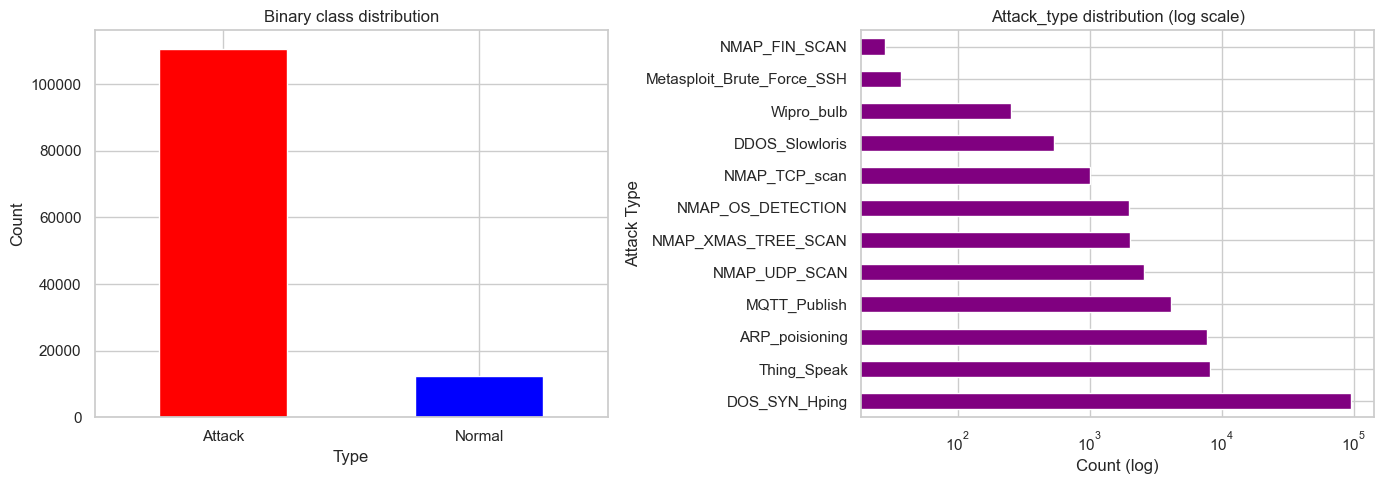

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# plotting attack vs normal
df["binary_label"].value_counts().plot(kind="bar", ax=ax[0], color=["red", "blue"])
ax[0].set_title("Binary class distribution"); ax[0].set_ylabel("Count"); ax[0].set_xlabel("Type")
ax[0].tick_params(axis="x", rotation=0)

# plotting attack type distibution
df["Attack_type"].value_counts().plot(kind="barh", ax=ax[1], color="purple")
ax[1].set_title("Attack_type distribution (log scale)"); ax[1].set_xscale("log") #log scale
ax[1].set_xlabel("Count (log)"); ax[1].set_ylabel("Attack Type")

plt.tight_layout(); plt.show()

Binary is roughly a 90/10 in favor of Attack.

'DOS_SYN_Hping' alone is 94,659 rows, while 'Metasploit_Brute_Force_SSH' has 37 and 'NMAP_FIN_SCAN' has 28. 


This drove three decisions: 
- **class weighting** where the model supports it 
- **stratified splitting** so rare classes appear in both halves
- **macro-averaged metrics** so those two tiny classes are not rounded away by the majority.

### 4.2 Categorical features (proto, service)

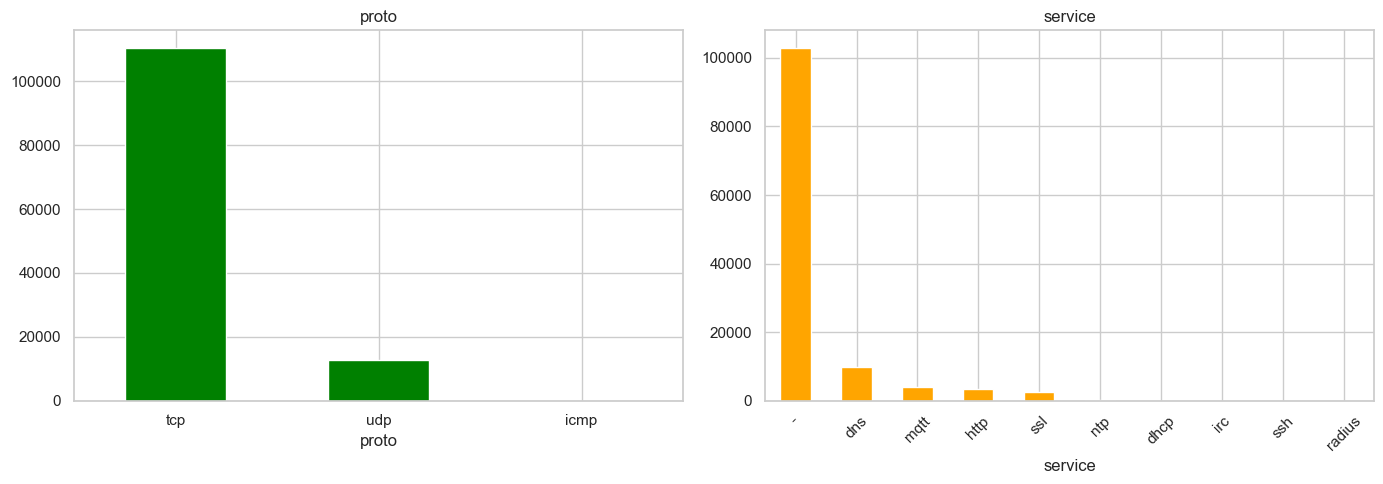

In [9]:
# Plotting protocol distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df["proto"].value_counts().plot(kind="bar", ax=ax[0], color="green")
ax[0].set_title("proto"); ax[0].tick_params(axis="x", rotation=0)

# Plotting service distribution
df["service"].value_counts().plot(kind="bar", ax=ax[1], color="orange")
ax[1].set_title("service"); ax[1].tick_params(axis="x", rotation=45)

plt.tight_layout(); plt.show()

'proto' is dominated by TCP 

'service' is mostly dominated the placeholder '-' (not identify an application protocol). This is becausec scan and flood traffic rarely complete enough of a handshake for a service to be inferred.

### 4.3 Feature correlation

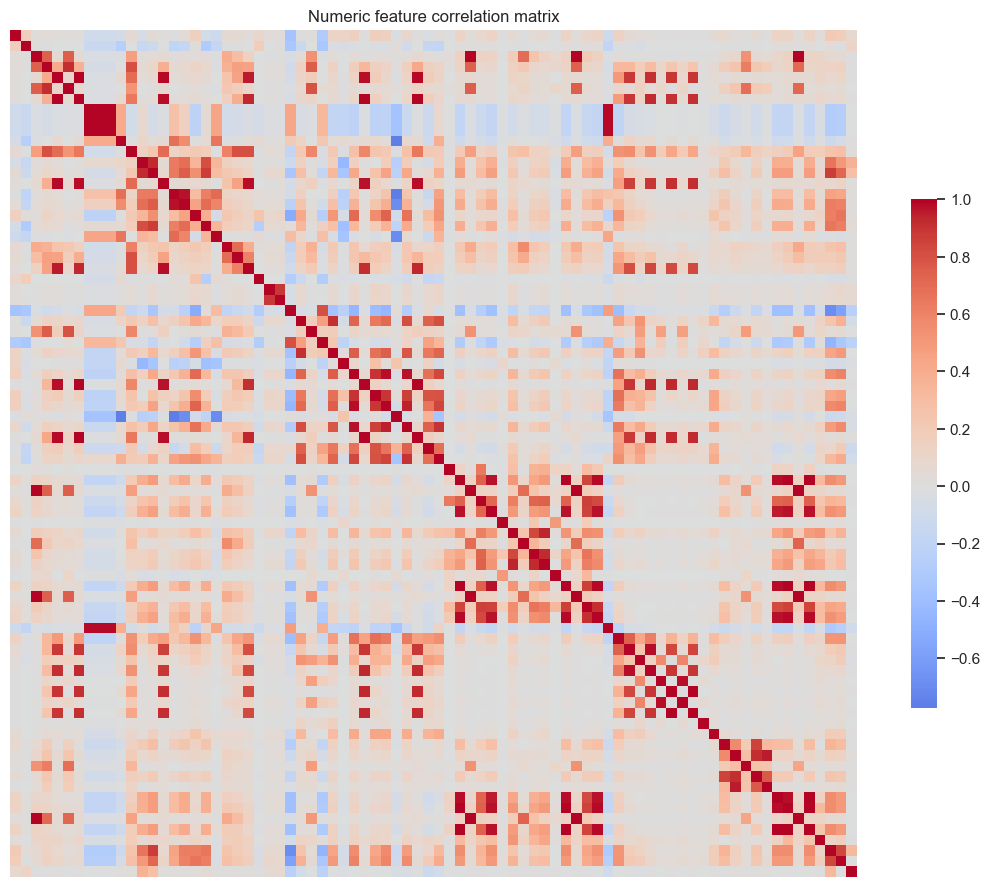

Highly correlated pairs (|r|>0.95): 52
('flow_duration', 'fwd_iat.tot', np.float64(1.0))
('flow_duration', 'flow_iat.tot', np.float64(1.0))
('flow_duration', 'idle.tot', np.float64(0.995))
('bwd_pkts_tot', 'bwd_data_pkts_tot', np.float64(0.993))
('bwd_pkts_tot', 'bwd_header_size_tot', np.float64(0.985))
('bwd_pkts_tot', 'flow_ACK_flag_count', np.float64(0.958))
('bwd_pkts_tot', 'bwd_pkts_payload.tot', np.float64(0.975))
('bwd_pkts_tot', 'flow_pkts_payload.tot', np.float64(0.983))
('bwd_data_pkts_tot', 'bwd_header_size_tot', np.float64(0.977))
('bwd_data_pkts_tot', 'bwd_pkts_payload.tot', np.float64(0.992))
('bwd_data_pkts_tot', 'flow_pkts_payload.tot', np.float64(0.992))
('fwd_pkts_per_sec', 'bwd_pkts_per_sec', np.float64(1.0))
('fwd_pkts_per_sec', 'flow_pkts_per_sec', np.float64(1.0))
('fwd_pkts_per_sec', 'payload_bytes_per_second', np.float64(0.984))
('bwd_pkts_per_sec', 'flow_pkts_per_sec', np.float64(1.0))


In [10]:
#isolate numeric columns
num = df.select_dtypes(include=[np.number])
num = num.loc[:, num.std() > 0]          # drop zero-variance columns for a cleaner view
# pearson correlation matrix
corr = num.corr()
# heatmap
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            xticklabels=False, yticklabels=False, cbar_kws={"shrink": .6})
plt.title("Numeric feature correlation matrix")
plt.show()
#identifying high correlation
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
# above 95%
high = [(a, b, round(upper.loc[a, b], 3))
        for a in upper.index for b in upper.columns
        if pd.notna(upper.loc[a, b]) and abs(upper.loc[a, b]) > 0.95]
print(f"Highly correlated pairs (|r|>0.95): {len(high)}")
for p in high[:15]:
    print(p)

52 feature pairs correlate above 0.95, several at exactly r = 1.000! 
The actual dimensionality of this feature set is well below 94.

### 4.4 Distributions of key flow features by class

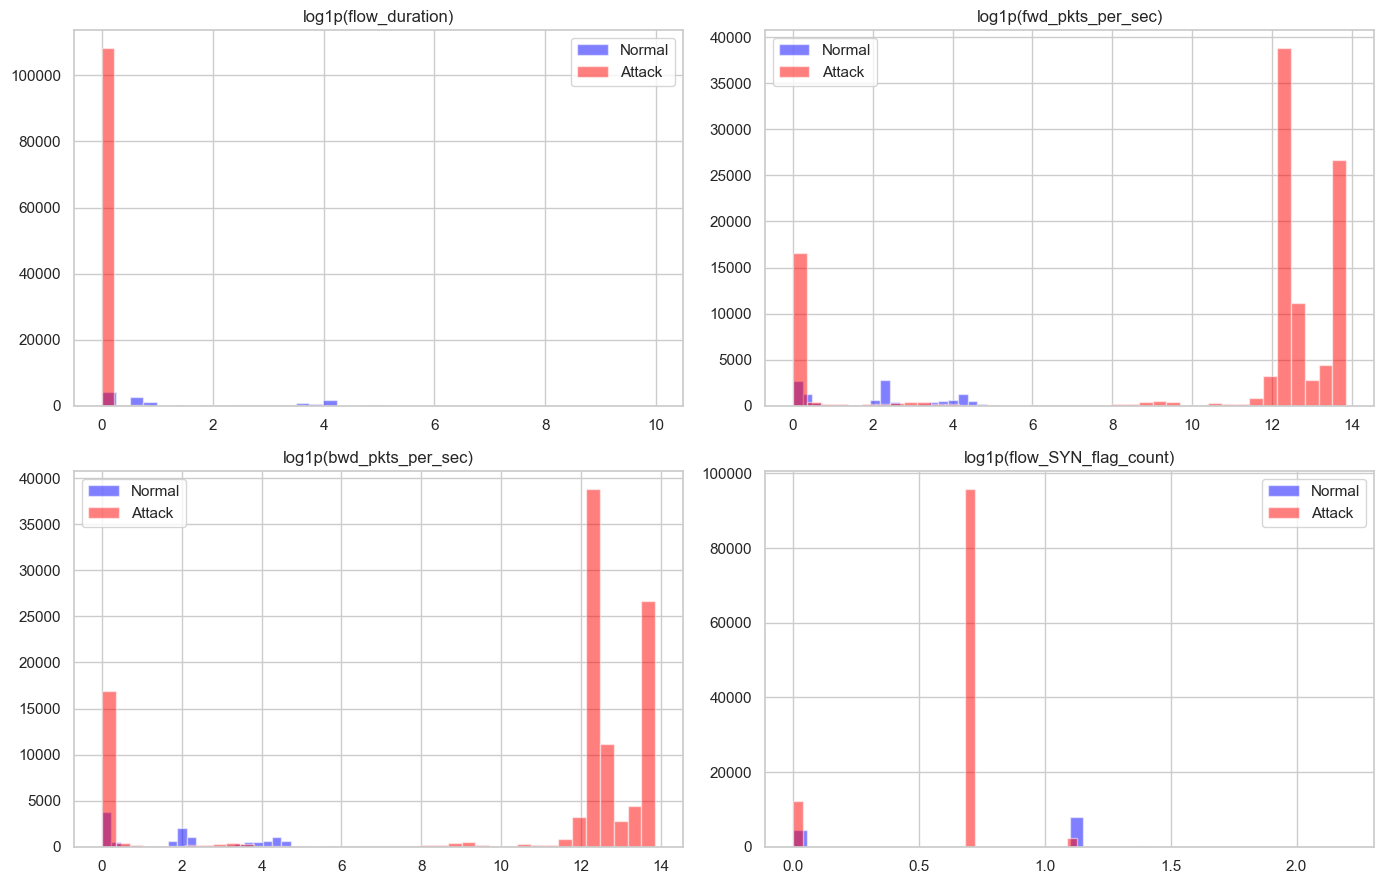

In [11]:
# features to look at
key_feats = ["flow_duration", "fwd_pkts_per_sec", "bwd_pkts_per_sec", "flow_SYN_flag_count"]
#a check to make sure they are there and correct
key_feats = [f for f in key_feats if f in df.columns]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
# looping through features
for f, axi in zip(key_feats, axes.ravel()):
    # attack binary
    for lbl, color in [("Normal", "blue"), ("Attack", "red")]:
        vals = df.loc[df["binary_label"] == lbl, f]
        axi.hist(np.log1p(vals.clip(lower=0)), bins=40, alpha=0.5, label=lbl, color=color)
    axi.set_title(f"log1p({f})"); axi.legend()
plt.tight_layout(); plt.show()

Normal and Attack traffic occupy visibly different regions on a log scale
- normal device traffic is long-lived and low-rate
- attack traffic is short and bursty.
  
Though the separation is not perfect, I think it is strong enough to expect the binary classificsation task to be succesful

## 5. Data Quality: Exploring How Many Distinct Flows There Actually Are

RT-IoT2022's attack traffic was synthetically generated. Flows in this dataset are near-identical by the nature of their
construction. Row count and the amount of actual independent information are not the same. This section attempts to quantify this gap to better determines how the train/test split has to be built.

### 5.1 Exact duplicates

In [12]:
# count rows belonging to a duplicate group
dup_any   = df.duplicated(keep=False).sum()      
# count redundant copies
dup_extra = df.duplicated().sum()                
print(f"Rows belonging to an exact-duplicate group : {dup_any:,} ({dup_any/len(df):.1%})")
print(f"Redundant copies                           : {dup_extra:,} ({dup_extra/len(df):.1%})")
#redundant copies by attack types
dup_by_class = (df.loc[df.duplicated(keep="first"), "Attack_type"]
                  .value_counts().rename("redundant_copies"))
# count the total number of rows for each type
tot_by_class = df["Attack_type"].value_counts().rename("rows")
#combine into df
dup_summary = pd.concat([tot_by_class, dup_by_class], axis=1).fillna(0).astype(int)
# derice percentof rows within each attack type that are redundant
dup_summary["pct_redundant"] = (100 * dup_summary["redundant_copies"] /
                                dup_summary["rows"]).round(1)
display(dup_summary.sort_values("redundant_copies", ascending=False))

Rows belonging to an exact-duplicate group : 10,154 (8.2%)
Redundant copies                           : 5,195 (4.2%)


,rows,redundant_copies,pct_redundant
Attack_type,,,
DOS_SYN_Hping,94659,4570,4.8
Thing_Speak,8108,454,5.6
ARP_poisioning,7750,125,1.6
Wipro_bulb,253,34,13.4
NMAP_UDP_SCAN,2590,6,0.2
MQTT_Publish,4146,4,0.1
DDOS_Slowloris,534,1,0.2
Metasploit_Brute_Force_SSH,37,1,2.7
NMAP_XMAS_TREE_SCAN,2010,0,0.0


5,195 rows are duplicative, concentrated in 'DOS_SYN_Hping' and
'Thing_Speak'. These will need to be removed

### 5.2 Near-duplicate flow groups

In [13]:
# flow_groups bins every feature by rank-percentile and hashes the result 
# two flows share a group if all 83 features agree to within a bin

#dropping the target labels
raw_feats = df.drop(columns=["Attack_type", "binary_label"])
# testing out different binning sizes
for nb in [20, 50, 200]:
    g = flow_groups(raw_feats, n_bins=nb)
    print(f"n_bins={nb:>4}:  {len(df):,} rows -> {len(np.unique(g)):,} distinct flow groups "
          f"({len(df)/len(np.unique(g)):.1f} rows per group)")

# how different attack types cluster
groups_all = flow_groups(raw_feats, n_bins=50)
#temporary df mapping each row type to its computed group
#Group by type to calculate summary metrics for each class.
per_class = (pd.DataFrame({"Attack_type": df["Attack_type"].values, "grp": groups_all})
               .groupby("Attack_type")
               .agg(rows=("grp", "size"), flow_groups=("grp", "nunique")))
per_class["rows_per_group"] = (per_class["rows"] / per_class["flow_groups"]).round(1)
display(per_class.sort_values("rows_per_group", ascending=False))

n_bins=  20:  123,117 rows -> 15,893 distinct flow groups (7.7 rows per group)
n_bins=  50:  123,117 rows -> 18,954 distinct flow groups (6.5 rows per group)
n_bins= 200:  123,117 rows -> 22,814 distinct flow groups (5.4 rows per group)


,rows,flow_groups,rows_per_group
Attack_type,,,
DOS_SYN_Hping,94659,229,413.4
NMAP_UDP_SCAN,2590,214,12.1
NMAP_XMAS_TREE_SCAN,2010,226,8.9
NMAP_OS_DETECTION,2000,233,8.6
NMAP_FIN_SCAN,28,14,2.0
ARP_poisioning,7750,5166,1.5
DDOS_Slowloris,534,349,1.5
NMAP_TCP_scan,1002,671,1.5
Wipro_bulb,253,216,1.2


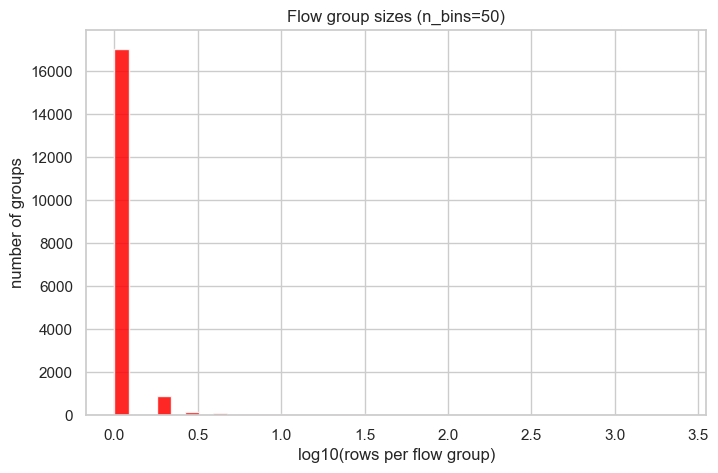

Largest groups (rows per group):
15189187920951265259    2399
6184023524692645565     2159
5072338920189449921     2149
11145732374435458149    2053
378437062378197493      1960


In [14]:
#visualize flow gorup sizes with hostogram
sizes = pd.Series(groups_all).value_counts()
plt.figure(figsize=(8, 5))
plt.hist(np.log10(sizes.values), bins=40, color="red", alpha=.85)
plt.xlabel("log10(rows per flow group)"); plt.ylabel("number of groups")
plt.title("Flow group sizes (n_bins=50)")
plt.show()

# look at top 5 largest group sizes
print("Largest groups (rows per group):")
print(sizes.head(5).to_string())

The row count seems to overstate the actual information content by roughly 6x times and the replication is uneven across classes

The replicated classes are the generated attack ones while the unreplicated ones are the genuinely captured device traffic. This is a fingerprint of how the synthetic data was generated are clearly evident.

This is consequential for modelling. A stratified split would treat those 413 near-copies as 413 independent observations and scatter them across train and test splits. A model can score well on a test flow it has effectively already been trained on. Therefore, two splits
will be built. A conventional random one and a flow-group split that keeps every group whole. The flow-group numbers are the ones this project will give more credence to.

## 6. Preprocessing & Evaluation

Order of operations:

1. one-hot encode proto and service
2. drop the 5,195 exact duplicates
3. build the splits
4. fit every transform inside a pipeline, so StandardScaler and PCA see training rows only

Two splits are constructed, both 75/25 and both using the same four models:

* **Random** — stratified random split. The conventional choice.
* **Flow-group** — StratifiedGroupKFold over the flow groups from before, which keeps every
  class represented in the test fold while guaranteeing that no group of near-identical flows is
  divided across train/test boundary.

In [15]:
# one hot encoding
feature_df = df.drop(columns=["Attack_type", "binary_label"]) #dropping the target labels
# into dummy variables
X_enc = pd.get_dummies(feature_df, columns=["proto", "service"], drop_first=False).astype(float)
print("Encoded feature matrix:", X_enc.shape)

# dropping exact duplicates to prevent leakage
keep   = ~df.duplicated(keep="first").values
X      = X_enc.values[keep]
y_multi = df["Attack_type"].values[keep]
y_bin   = df["binary_label"].values[keep]
# generate flow groups based only on the retained unique rows.
groups  = flow_groups(raw_feats.loc[keep], n_bins=50)
print(f"After dropping exact duplicates: {X.shape[0]:,} rows "
      f"({len(X_enc) - X.shape[0]:,} removed), {len(np.unique(groups)):,} flow groups")

# split 1: stratified random 
tr_rand, te_rand = train_test_split(np.arange(len(X)), test_size=0.25,
                                    random_state=RANDOM_STATE, stratify=y_multi)

# split 2: the flow-group 
sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
tr_grp, te_grp = next(sgkf.split(np.zeros(len(y_multi)), y_multi, groups))

# store both in a dictionary for easy comparison
SPLITS = {
    "Random":     dict(tr=tr_rand, te=te_rand),
    "Flow-group": dict(tr=tr_grp,  te=te_grp),
}
#printing validation metrics
for name, s in SPLITS.items():
    print(f"{name:<12s} train={len(s['tr']):>7,}  test={len(s['te']):>7,}  "
          f"classes in test={len(np.unique(y_multi[s['te']]))}/12  "
          f"groups shared across the split={len(set(groups[s['tr']]) & set(groups[s['te']])):,}")

Encoded feature matrix: (123117, 94)
After dropping exact duplicates: 117,922 rows (5,195 removed), 18,954 flow groups
Random       train= 88,441  test= 29,481  classes in test=12/12  groups shared across the split=1,021
Flow-group   train= 84,454  test= 33,468  classes in test=12/12  groups shared across the split=0


After dropping exact duplicates: 117,922 rows (5,195 removed), 18,948 flow groups


Random       train= 88,441  test= 29,481  classes in test=12/12  groups shared across the split=1,021
Flow-group   train= 84,001  test= 33,921  classes in test=12/12  groups shared across the split=0


### 6.1 Novelty of each test set

Checking what the two splits actually have produced.

Random                     identical(<1e-6):  0.02%   near(<0.01): 85.98%   median gap: 0.00016
Flow-group                 identical(<1e-6):  0.00%   near(<0.01): 20.28%   median gap: 0.02522


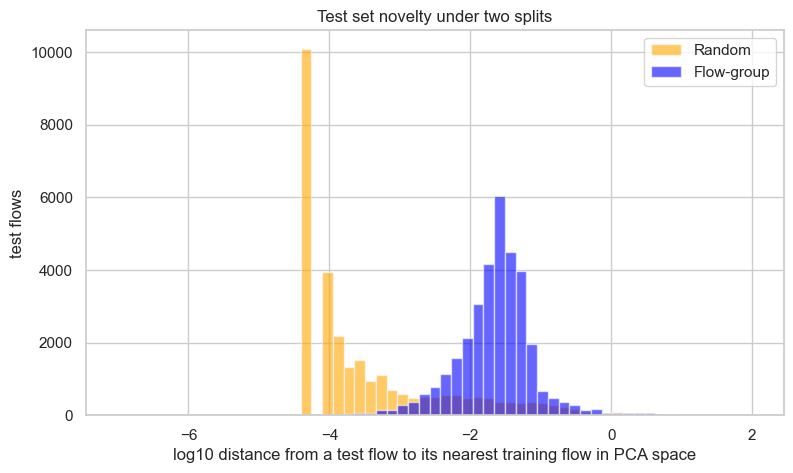

In [16]:
#utilizng the novelty gap function to calculate the distance from each test flow to its nearest training flow
gaps = {name: novelty_gap(X, s["tr"], s["te"], name) for name, s in SPLITS.items()}

plt.figure(figsize=(9, 5))
#60 evenly spaced bins
bins = np.linspace(-7, 2, 60)
# Loop through the calculated distances for both splits 
# Orange first split (Random) and Blue second split (Flow-group).
for (name, d), c in zip(gaps.items(), ["orange", "blue"]):
    plt.hist(np.log10(np.maximum(d, 1e-7)), bins=bins, alpha=.6, label=name, color=c)
plt.xlabel("log10 distance from a test flow to its nearest training flow in PCA space")
plt.ylabel("test flows"); plt.legend(); plt.title("Test set novelty under two splits")
plt.show()

The two splits produce very different test sets from the same flows:

For the random split: a small amount are identical, 86% of test flows sit basically on top of a training flow and the median test flow is only 0.00016 away.

The flow-group split: no identicals, only 20% near, and expands the median gap by a factor of about 150 to 0.02522

This gives credence to the superiority of the flow-group split. Furthermore, for future results, if the two splits agree the results can be seen as robust. If however, they diverge, the flow-group figure is the one that is most likely to reflect performance on
genuinely unseen traffic and the result to be more readily trusted.

## 7. PCA and t-SNE

* For Logistic Regression, Naive Bayes and Random Forest, PCA is used for exploration only
  Those models are fit on the full 94-column encoded feature set.
* For KNN, PCA is a fitted stage of the pipeline (StandardScaler -> PCA(95% var) -> KNN),
  refit on the training rows of whichever split is being evaluated
* PCA is also the distance space for the novelty diagnostic from the previous section

The curves below are fit on the flow-group training set only

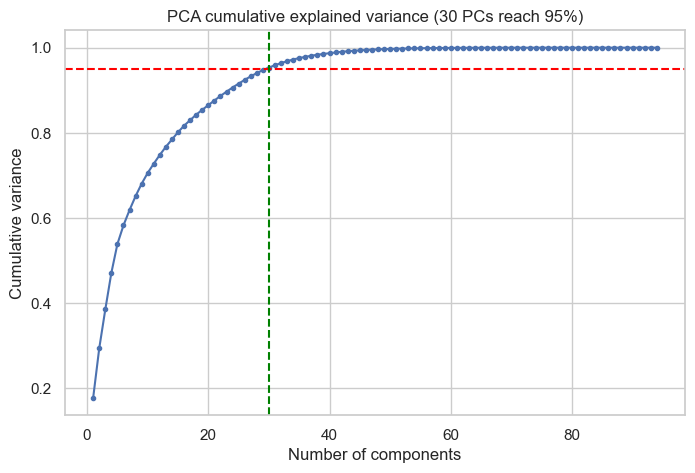

30 components explain >=95% of variance (from 94 features).


In [17]:
# Extract the primary training features
X_train_primary = X[SPLITS[PRIMARY]["tr"]]
# initialize a StandardScaler and fit it to the training data
sc_eda = StandardScaler().fit(X_train_primary)
# scale the data, then initialize and fit full PCA model 
pca_full = PCA(random_state=RANDOM_STATE).fit(sc_eda.transform(X_train_primary))
# cumulative sum of the variance
cum = np.cumsum(pca_full.explained_variance_ratio_)
# exact number of components needed to explain at least 95% of the total variance.
n95 = int(np.argmax(cum >= 0.95) + 1)

#plot pca
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum) + 1), cum, marker=".")
#lines to mark elbow
plt.axhline(0.95, color="red", ls="--"); plt.axvline(n95, color="green", ls="--")
plt.title(f"PCA cumulative explained variance ({n95} PCs reach 95%)")
plt.xlabel("Number of components"); plt.ylabel("Cumulative variance")
plt.show()
# print num of components
print(f"{n95} components explain >=95% of variance (from {X_train_primary.shape[1]} features).")

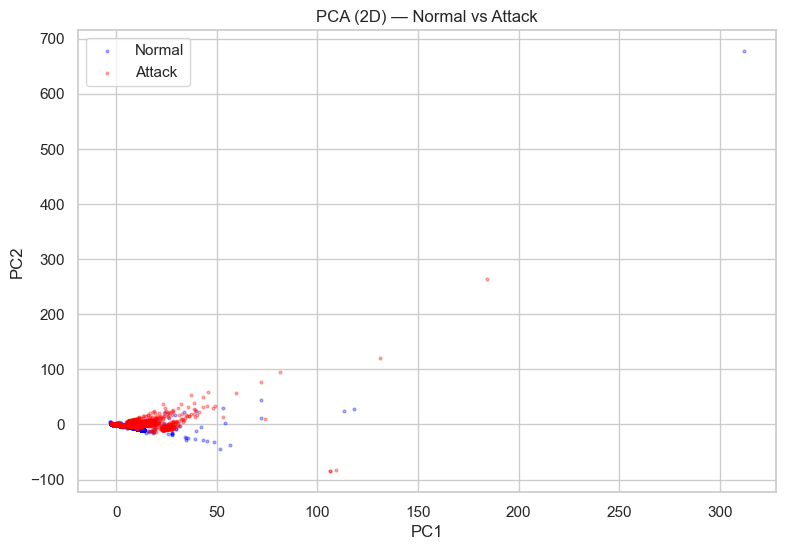

In [18]:
# restricted to 2 principal components to allow for 2D visualization of binary attack vs normal
proj = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(
    sc_eda.transform(X_train_primary))

plt.figure(figsize=(9, 6))
# iterate through the classes with their assigned colors to plot them
for lbl, color in [("Normal", "blue"), ("Attack", "red")]:
    m = y_bin[SPLITS[PRIMARY]["tr"]] == lbl
    plt.scatter(proj[m, 0], proj[m, 1], s=4, alpha=0.3, label=lbl, color=color)
plt.legend(); plt.title("PCA (2D) — Normal vs Attack")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()

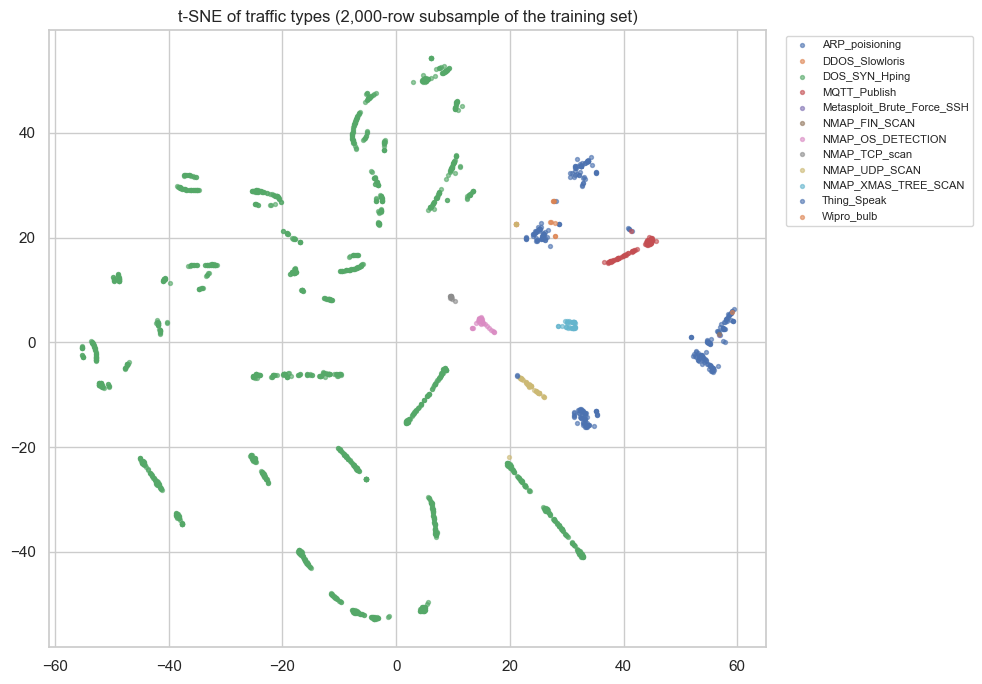

In [19]:
# t-SNE ran on a 2,000-row stratified subsample of the training set
tr_primary = SPLITS[PRIMARY]["tr"]

sub_idx, _ = train_test_split(np.arange(len(tr_primary)), train_size=2000,
                              random_state=RANDOM_STATE, stratify=y_multi[tr_primary])#  stratify=y_multi[tr_primary] ensure the class proportions
# reduce the data to 2 dimensions for visualization with init="pca" more accurate than random initialization.
emb = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca",
           perplexity=30).fit_transform(sc_eda.transform(X_train_primary)[sub_idx])
sub_labels = y_multi[tr_primary][sub_idx] #labels

#plotting results
plt.figure(figsize=(10, 7))
for lbl in np.unique(sub_labels):
    m = sub_labels == lbl
    plt.scatter(emb[m, 0], emb[m, 1], s=8, alpha=0.6, label=lbl)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.title("t-SNE of traffic types (2,000-row subsample of the training set)")
plt.tight_layout(); plt.show()

30 of the 94 components carry 95% of the variance!

The 2-D PCA projection seems to separate most Normal traffic from Attack decently well already.

t-SNE shows the multi-class structure with several attack types forming tight and well-isolated islands, while the rarer classes sit as small clusters near larger ones. 

## 8. Binary Classification — Normal vs Attack

Attack is the positive class, and the target is a recall score >= 0.95. Each model is evaluated under both splits.

In [20]:
# dictionaries to store the evaluation results
bin_results, bin_fitted = {}, {}

# helper function to train and evaluate binary classification models
def eval_binary(split_name):
    s = SPLITS[split_name]
    # train the model and get predictions
    res, fit = run_binary(X, y_bin, s["tr"], s["te"])
    # save results
    bin_results[split_name], bin_fitted[split_name] = res, fit
    #summary
    print(f"Binary — {split_name} split  (train={len(s['tr']):,}, test={len(s['te']):,})")
    display(res.round(4))

# random split binary results
eval_binary("Random")

Binary — Random split  (train=88,441, test=29,481)


,Recall,Precision,F1,ROC_AUC,Seconds
Logistic Regression,0.9714,0.9991,0.9850,0.9970,0.8
Naive Bayes,0.9745,0.9641,0.9693,0.9779,0.2
Random Forest,0.9995,0.9990,0.9993,0.9996,0.8
KNN (PCA),0.9978,0.9979,0.9978,0.9979,1.1


In [21]:
# flow-group split binary results
eval_binary("Flow-group")

Binary — Flow-group split  (train=84,454, test=33,468)


,Recall,Precision,F1,ROC_AUC,Seconds
Logistic Regression,0.9760,0.9990,0.9874,0.9963,0.5
Naive Bayes,0.9800,0.9683,0.9742,0.8554,0.2
Random Forest,0.9997,0.9991,0.9994,0.9996,0.7
KNN (PCA),0.9991,0.9980,0.9985,0.9974,1.1


In [22]:
#comparison of random v flow group
for metric in ["Recall", "F1", "ROC_AUC"]:
    print(f"\n=== Binary {metric} ===")
    display(split_table(bin_results, metric).round(4))


=== Binary Recall ===


,Random,Flow-group
Logistic Regression,0.9714,0.9760
Naive Bayes,0.9745,0.9800
Random Forest,0.9995,0.9997
KNN (PCA),0.9978,0.9991



=== Binary F1 ===


,Random,Flow-group
Logistic Regression,0.9850,0.9874
Naive Bayes,0.9693,0.9742
Random Forest,0.9993,0.9994
KNN (PCA),0.9978,0.9985



=== Binary ROC_AUC ===


,Random,Flow-group
Logistic Regression,0.9970,0.9963
Naive Bayes,0.9779,0.8554
Random Forest,0.9996,0.9996
KNN (PCA),0.9979,0.9974


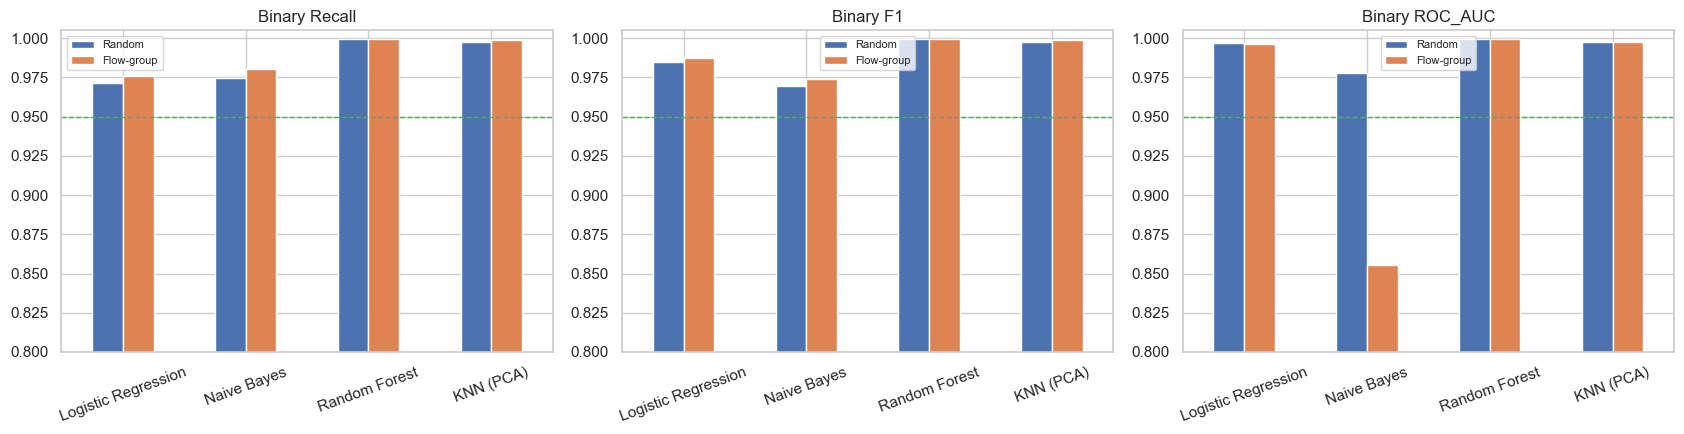

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
# plotting the 3 evaluation metrics we want to visualize
for axi, metric in zip(axes, ["Recall", "F1", "ROC_AUC"]):
    split_table(bin_results, metric).plot(kind="bar", ax=axi)
    axi.set_title(f"Binary {metric}"); axi.set_ylim(0.80, 1.005) #zoomed in view
    axi.axhline(0.95, color="g", ls="--", lw=1) #target goal
    axi.tick_params(axis="x", rotation=20); axi.legend(fontsize=8)
plt.tight_layout(); plt.show()

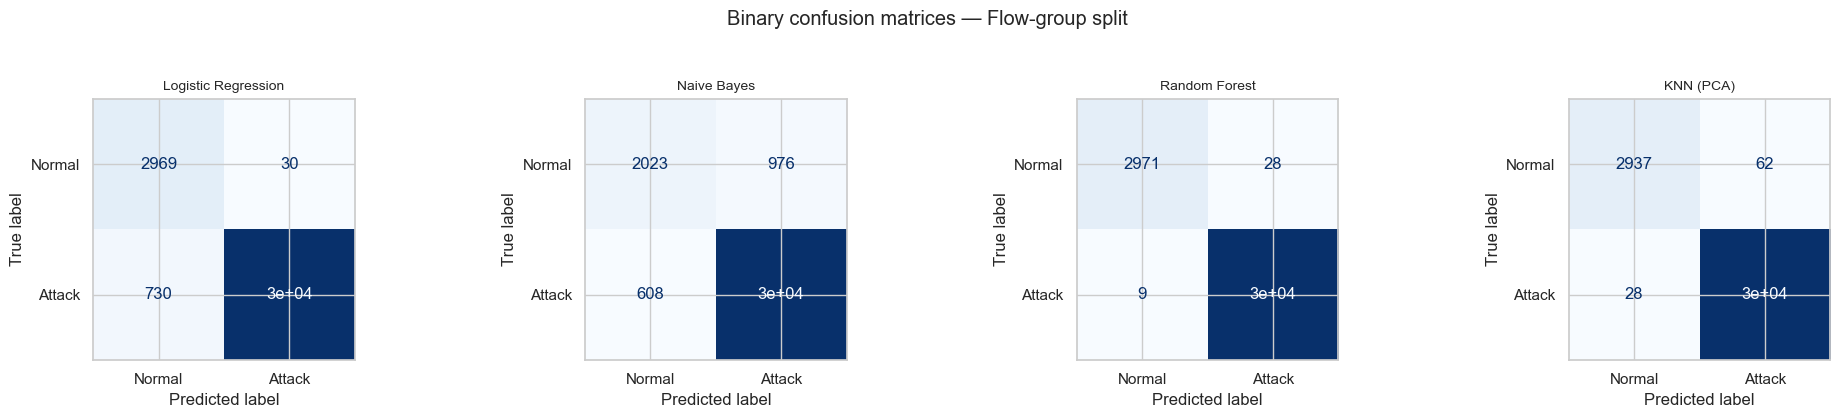

In [24]:
# confusion matrixes for the 4 models
s = SPLITS[PRIMARY]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for axi, (name, r) in zip(axes, bin_fitted[PRIMARY].items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_bin[s["te"]], r["pred"], labels=["Normal", "Attack"]),
        display_labels=["Normal", "Attack"]).plot(ax=axi, colorbar=False, cmap="Blues")
    axi.set_title(name, fontsize=10)
    
plt.suptitle(f"Binary confusion matrices — {PRIMARY} split", y=1.04)
plt.tight_layout(); plt.show()

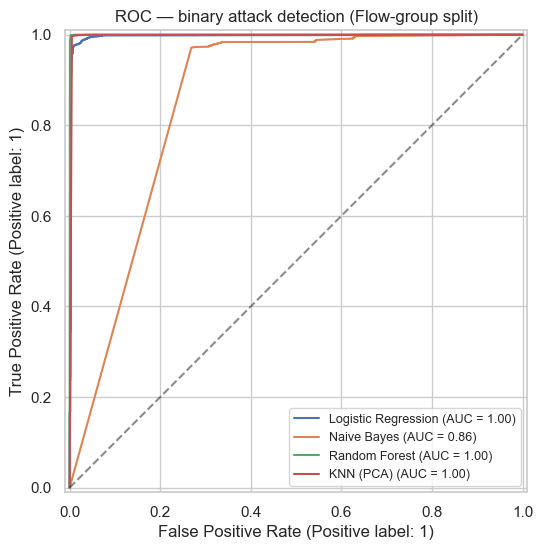

In [25]:
# plotting ROC Curves for Binary Attack Detection
plt.figure(figsize=(8, 6))
y_true = (y_bin[SPLITS[PRIMARY]["te"]] == POS).astype(int)
for name, r in bin_fitted[PRIMARY].items():
    #plot the ROC curve for each model using its predicted probabilities
    RocCurveDisplay.from_predictions(y_true, r["proba"], name=name, ax=plt.gca())
plt.plot([0, 1], [0, 1], "k--", alpha=.5)
plt.title(f"ROC — binary attack detection ({PRIMARY} split)")
plt.legend(fontsize=9, loc="lower right"); plt.show()

In [26]:
#results for the best binary classifier
best_bin = bin_results[PRIMARY]["Recall"].astype(float).idxmax()
print(f"Best binary model on the {PRIMARY} split (by attack recall): {best_bin}\n")
print(classification_report(y_bin[SPLITS[PRIMARY]["te"]],
                            bin_fitted[PRIMARY][best_bin]["pred"], digits=4))

Best binary model on the Flow-group split (by attack recall): Random Forest

              precision    recall  f1-score   support

      Attack     0.9991    0.9997    0.9994     30469
      Normal     0.9970    0.9907    0.9938      2999

    accuracy                         0.9989     33468
   macro avg     0.9980    0.9952    0.9966     33468
weighted avg     0.9989    0.9989    0.9989     33468



### 8.1 Reading the binary results

Every model clears the 0.95 recall target on both splits!

Random Forest is the clear winner, with recall 0.9997, precision 0.9991 and ROC-AUC 0.9996
on the flow-group split. It had only 9 missed attacks out of 30,469 and 28 false alarms out of 2,999
normal flows.

Interestingly, the binary detection was insensitive to the splitting strategy. Every model scores marginally higher on the supposedly harder flow-group split than on the random split. The models are not relying on having seen a near-identical flow.

The one exception is Naive Bayes's ROC-AUC, which drops from 0.9779 to 0.8554 even as its recall and precision improve. This indicates that the thresholded decisions get better while the ranking of borderline cases gets worse.

## 9. Multi-Class Classification — Attack Type

All 12 traffic types, both splits, the same four models. Macro-F1 and balanced accuracy are
the metrics to read with accuracy reported to show how misleading it is on this distribution.

In [27]:
# dictionaries to store the evaluation results
multi_results, multi_fitted = {}, {}
# helper function to train and evaluate muticlass classification models
def eval_multi(split_name):
    s = SPLITS[split_name]
    res, fit = run_multiclass(X, y_multi, s["tr"], s["te"])
    multi_results[split_name], multi_fitted[split_name] = res, fit
    print(f"Multi-class — {split_name} split  (train={len(s['tr']):,}, test={len(s['te']):,})")
    display(res.round(4))

# random split muticlass results
eval_multi("Random")

Multi-class — Random split  (train=88,441, test=29,481)


,Macro_F1,Weighted_F1,Macro_Recall,Balanced_Acc,Accuracy,ROC_AUC_ovr,Seconds
Logistic Regression,0.8305,0.9895,0.9731,0.9731,0.9885,0.9943,4.3
Naive Bayes,0.5903,0.9079,0.8125,0.8125,0.8994,0.9909,0.2
Random Forest,0.9901,0.9986,0.9936,0.9936,0.9986,0.9999,0.7
KNN (PCA),0.9698,0.9954,0.9745,0.9745,0.9954,0.9960,1.0


In [28]:
# flow-group split multiclass results
eval_multi("Flow-group")

Multi-class — Flow-group split  (train=84,454, test=33,468)


,Macro_F1,Weighted_F1,Macro_Recall,Balanced_Acc,Accuracy,ROC_AUC_ovr,Seconds
Logistic Regression,0.8196,0.9898,0.9639,0.9639,0.9887,0.9951,4.1
Naive Bayes,0.5902,0.9220,0.8083,0.8083,0.9152,0.9900,0.2
Random Forest,0.9862,0.9986,0.9772,0.9772,0.9986,0.9992,0.6
KNN (PCA),0.9736,0.9966,0.9697,0.9697,0.9966,0.9902,0.9



=== Multi-class Macro_F1 ===


,Random,Flow-group
Logistic Regression,0.8305,0.8196
Naive Bayes,0.5903,0.5902
Random Forest,0.9901,0.9862
KNN (PCA),0.9698,0.9736



=== Multi-class Macro_Recall ===


,Random,Flow-group
Logistic Regression,0.9731,0.9639
Naive Bayes,0.8125,0.8083
Random Forest,0.9936,0.9772
KNN (PCA),0.9745,0.9697



=== Multi-class Balanced_Acc ===


,Random,Flow-group
Logistic Regression,0.9731,0.9639
Naive Bayes,0.8125,0.8083
Random Forest,0.9936,0.9772
KNN (PCA),0.9745,0.9697



=== Multi-class Weighted_F1 ===


,Random,Flow-group
Logistic Regression,0.9895,0.9898
Naive Bayes,0.9079,0.9220
Random Forest,0.9986,0.9986
KNN (PCA),0.9954,0.9966


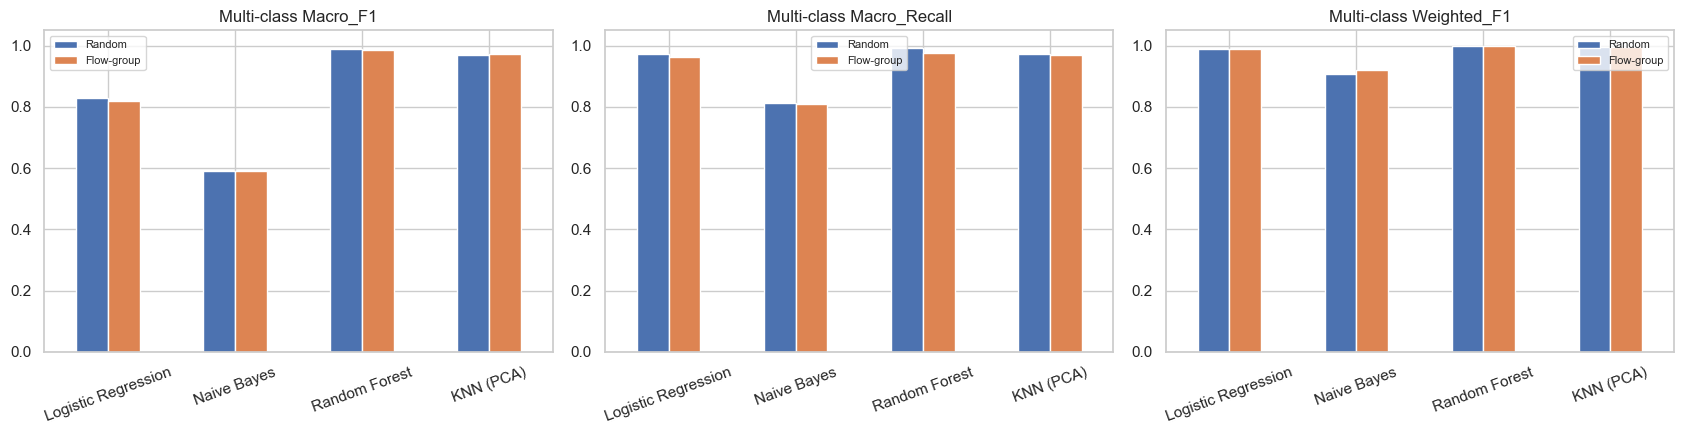

In [29]:
#comparison of random v flow group
for metric in ["Macro_F1", "Macro_Recall", "Balanced_Acc", "Weighted_F1"]:
    print(f"\n=== Multi-class {metric} ===")
    display(split_table(multi_results, metric).round(4))
    
# plotting the 3 evaluation metrics we want to visualize
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for axi, metric in zip(axes, ["Macro_F1", "Macro_Recall", "Weighted_F1"]):
    split_table(multi_results, metric).plot(kind="bar", ax=axi)
    axi.set_title(f"Multi-class {metric}"); axi.set_ylim(0, 1.05)
    axi.tick_params(axis="x", rotation=20); axi.legend(fontsize=8)
plt.tight_layout(); plt.show()

Best multi-class model on the Flow-group split (by macro-F1): Random Forest


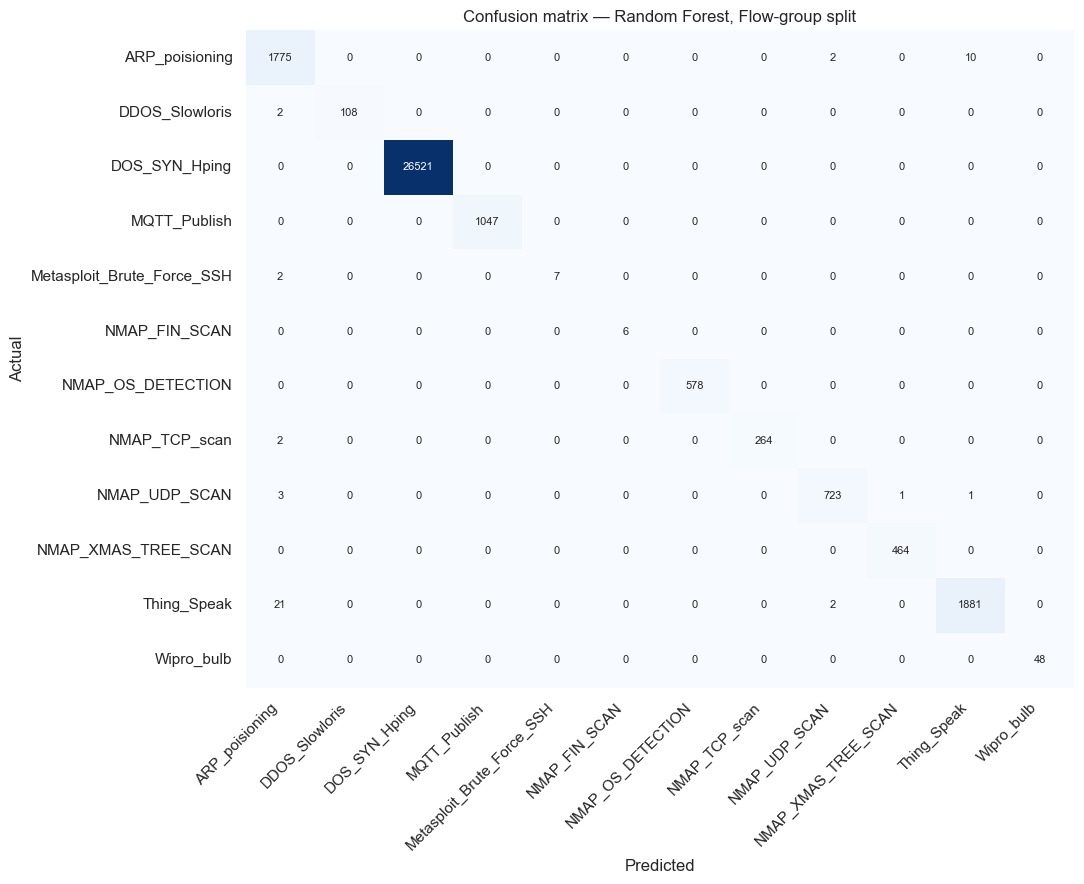

In [30]:
# confusion matrixes for the random forest, the best model
classes = np.unique(y_multi)
best_multi = multi_results[PRIMARY]["Macro_F1"].astype(float).idxmax()
print(f"Best multi-class model on the {PRIMARY} split (by macro-F1): {best_multi}")

s = SPLITS[PRIMARY]
cm = confusion_matrix(y_multi[s["te"]], multi_fitted[PRIMARY][best_multi]["pred"], labels=classes)
plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=classes, yticklabels=classes, annot_kws={"size": 8})
plt.title(f"Confusion matrix — {best_multi}, {PRIMARY} split")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

In [31]:
# breakdown of scores for per class 
print(f"Per-class report — {best_multi}, {PRIMARY} split\n")
print(classification_report(y_multi[s["te"]], multi_fitted[PRIMARY][best_multi]["pred"],
                            labels=classes, digits=4, zero_division=0))

Per-class report — Random Forest, Flow-group split

                            precision    recall  f1-score   support

            ARP_poisioning     0.9834    0.9933    0.9883      1787
            DDOS_Slowloris     1.0000    0.9818    0.9908       110
             DOS_SYN_Hping     1.0000    1.0000    1.0000     26521
              MQTT_Publish     1.0000    1.0000    1.0000      1047
Metasploit_Brute_Force_SSH     1.0000    0.7778    0.8750         9
             NMAP_FIN_SCAN     1.0000    1.0000    1.0000         6
         NMAP_OS_DETECTION     1.0000    1.0000    1.0000       578
             NMAP_TCP_scan     1.0000    0.9925    0.9962       266
             NMAP_UDP_SCAN     0.9945    0.9931    0.9938       728
       NMAP_XMAS_TREE_SCAN     0.9978    1.0000    0.9989       464
               Thing_Speak     0.9942    0.9879    0.9910      1904
                Wipro_bulb     1.0000    1.0000    1.0000        48

                  accuracy                         0.9986     

In [32]:
# Per-class recall for every model, rarest classes first
recall_tbl = pd.DataFrame({
    name: pd.Series(recall_score(y_multi[s["te"]], r["pred"], labels=classes,
                                 average=None, zero_division=0), index=classes)
    for name, r in multi_fitted[PRIMARY].items()})
recall_tbl.insert(0, "train_rows", pd.Series(y_multi[s["tr"]]).value_counts().reindex(classes).values)
recall_tbl.insert(1, "test_rows",  pd.Series(y_multi[s["te"]]).value_counts().reindex(classes).values)
print(f"Per-class RECALL — {PRIMARY} split")
display(recall_tbl.sort_values("train_rows").round(4))

Per-class RECALL — Flow-group split


,train_rows,test_rows,Logistic Regression,Naive Bayes,Random Forest,KNN (PCA)
NMAP_FIN_SCAN,22,6,1.0000,1.0000,1.0000,1.0000
Metasploit_Brute_Force_SSH,27,9,0.8889,0.8889,0.7778,0.8889
Wipro_bulb,171,48,0.9167,0.3750,1.0000,0.8333
DDOS_Slowloris,423,110,0.9818,0.9818,0.9818,0.9818
NMAP_TCP_scan,736,266,0.9925,0.9925,0.9925,0.9925
NMAP_OS_DETECTION,1422,578,1.0000,1.0000,1.0000,1.0000
NMAP_XMAS_TREE_SCAN,1546,464,1.0000,1.0000,1.0000,1.0000
NMAP_UDP_SCAN,1856,728,0.9808,0.9574,0.9931,0.9904
MQTT_Publish,3095,1047,1.0000,0.9990,1.0000,0.9981
Thing_Speak,5750,1904,0.9322,0.1528,0.9879,0.9674


In [33]:
# Sensitivity of the best model per-class recall by the splitting strategy.
comp = pd.DataFrame({
    name: pd.Series(recall_score(y_multi[SPLITS[name]["te"]],
                                 multi_fitted[name][best_multi]["pred"],
                                 labels=classes, average=None, zero_division=0), index=classes)
    for name in SPLITS})
comp["difference"] = (comp["Flow-group"] - comp["Random"]).round(4)
print(f"Per-class recall by split — {best_multi}")
display(comp.round(4).sort_values("difference"))

Per-class recall by split — Random Forest


,Random,Flow-group,difference
Metasploit_Brute_Force_SSH,1.0000,0.7778,-0.2222
NMAP_TCP_scan,1.0000,0.9925,-0.0075
DDOS_Slowloris,0.9850,0.9818,-0.0031
Thing_Speak,0.9901,0.9879,-0.0022
ARP_poisioning,0.9948,0.9933,-0.0015
DOS_SYN_Hping,1.0000,1.0000,0.0000
NMAP_FIN_SCAN,1.0000,1.0000,0.0000
NMAP_OS_DETECTION,1.0000,1.0000,0.0000
NMAP_UDP_SCAN,0.9923,0.9931,0.0009
MQTT_Publish,0.9990,1.0000,0.0010


### 9.1 Reading the multi-class results

Random Forest is again the best model, with a macro-F1 0.9862 and a macro-recall 0.9772 on the
flow-group split. Unlike the binary task, the multi-class result is, in fact, sensitive to the splitting
strategy.

Three model-level observations:

* **Naive Bayes is unusable here** A macro-F1 0.59 under both splits. Its conditional-independence
  assumption is directly contradicted by the 52 feature pairs correlating above 0.95. It collapses on Thing_Speak (recall 0.15), ARP_poisioning (0.35) and Wipro_bulb (0.38) while scoring 1.00 on DOS_SYN_Hping.
* **Logistic Regression trades precision for recall.** It reaches 0.9639 macro-recall but only
  0.8196 macro-F1. class_weight="balanced" buys rare-class recall by over-predicting those
  classes, and macro-F1 charges for the false positives that macro-recall ignores. 
* **KNN improves on the harder split** A macro-F1 0.9698 to 0.9736

## 10. KNN — Feature Spaces

KNN is valuable model to compare against because its single assumption is that class membership is locally constant. In a funny way, the metric chosen is the model itself and so the space it operates in needs to be chosen deliberately. For this project, PCA was used to reduce the feature space down. This made sense because of the highly correlated redundant features in the set and to combat the curse of dimensionality that can plague KNN. But what did this reduced feature space actually give us? (A perosonal curiosity question more than anything)

In [34]:
s = SPLITS[PRIMARY]
#dictionary of model vartiants
knn_variants = {
    #full set
    "KNN (all 94 features)": Pipeline([
        ("scale", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5, n_jobs=-1))]),
    # reduced pca set
    "KNN (PCA)": Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=PCA_VAR, random_state=RANDOM_STATE)),
        ("clf", KNeighborsClassifier(n_neighbors=5, n_jobs=-1))]),
}

# Run the binary classification
print(f"Binary task — {PRIMARY} split:")
knn_bin, _ = run_binary(X, y_bin, s["tr"], s["te"], models=knn_variants)
display(knn_bin.round(4))

#Run the multi-class classification
print(f"Multi-class task — {PRIMARY} split:")
knn_multi, _ = run_multiclass(X, y_multi, s["tr"], s["te"], models=knn_variants)
display(knn_multi.round(4))

# extract the number of components retained by PCA from the fitted pipeline
n_pca = knn_variants["KNN (PCA)"].named_steps["pca"].n_components_
#summary
print(f"\nPCA retained {n_pca} of {X.shape[1]} dimensions at {PCA_VAR:.0%} variance.")

Binary task — Flow-group split:


,Recall,Precision,F1,ROC_AUC,Seconds
KNN (all 94 features),0.9990,0.998,0.9985,0.9977,1.6
KNN (PCA),0.9991,0.998,0.9985,0.9974,1.0


Multi-class task — Flow-group split:


,Macro_F1,Weighted_F1,Macro_Recall,Balanced_Acc,Accuracy,ROC_AUC_ovr,Seconds
KNN (all 94 features),0.9700,0.9967,0.9715,0.9715,0.9967,0.9914,1.6
KNN (PCA),0.9736,0.9966,0.9697,0.9697,0.9966,0.9902,1.1



PCA retained 30 of 94 dimensions at 95% variance.


The honest conclusion is that PCA makes KNN cheaper here but not better. The metrics remain very close.

It is impressive that KNN ranks second overall on macro-F1, which is a strong showing for such a model. Beauty in simplicity sometimes.

## 11. Looking at Random Forest's Feature Importances

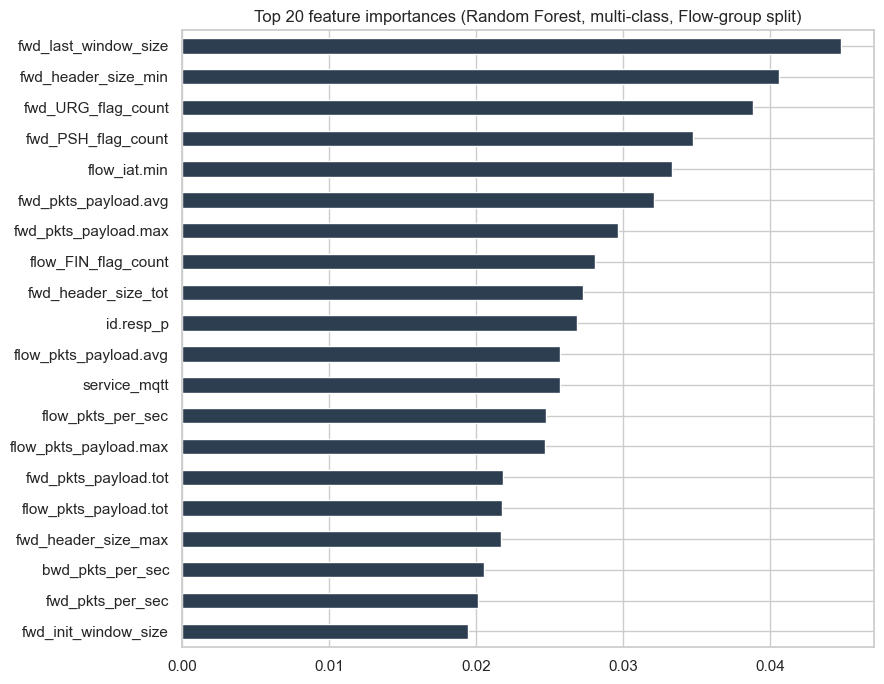

,importance
fwd_last_window_size,0.0448
fwd_header_size_min,0.0406
fwd_URG_flag_count,0.0388
fwd_PSH_flag_count,0.0347
flow_iat.min,0.0333
fwd_pkts_payload.avg,0.0321
fwd_pkts_payload.max,0.0296
flow_FIN_flag_count,0.0281
fwd_header_size_tot,0.0273
id.resp_p,0.0269


In [35]:
# extracting the fitted Random Forest model for the primary split from multi-class 
rf = multi_fitted[PRIMARY]["Random Forest"]["model"]
# calculate feature importances
imp = pd.Series(rf.feature_importances_,
                index=X_enc.columns).sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 7))
# plotting top 20 feature importances
imp[::-1].plot(kind="barh", color="#2c3e50")
plt.title(f"Top 20 feature importances (Random Forest, multi-class, {PRIMARY} split)")
plt.tight_layout(); plt.show()
display(imp.round(4).to_frame("importance"))

My thinking was this might be more insightful, but the importances are pretty flat.  The top feature carries only
0.045 and the twentieth still carries 0.019. This is probably an artifact of 52 near-collinear pairs that
split their shared importance among themselves. The ranking shows which groups of features
matter rather than any single decisive column. 

That said, the composition makes sense! TCP window and header sizes, flag counts, timing, and payload statistics are the fingerprints for discerning what class. That is also what makes Normal versus Attack so separable in this dataset.

## 12. Summary of Random Forest Results (Best Model)

In [36]:
# df of RF results
summary = pd.DataFrame({
    "Binary Recall (Attack)": split_table(bin_results, "Recall").loc["Random Forest"],
    "Binary ROC-AUC":         split_table(bin_results, "ROC_AUC").loc["Random Forest"],
    "Multi Macro-F1":         split_table(multi_results, "Macro_F1").loc["Random Forest"],
    "Multi Macro-Recall":     split_table(multi_results, "Macro_Recall").loc["Random Forest"],
}).round(4)
print("Random Forest under both splitting strategies")
display(summary)

Random Forest under both splitting strategies


,Binary Recall (Attack),Binary ROC-AUC,Multi Macro-F1,Multi Macro-Recall
Random,0.9995,0.9996,0.9901,0.9936
Flow-group,0.9997,0.9996,0.9862,0.9772
